# Thematic Trends Analysis

`Overview`
This notebook focuses on text analysis and topic modeling of EU Horizon project descriptions:
- Preprocessing text data (tokenization, stopword removal, lemmatization)
- Implementing Latent Dirichlet Allocation (LDA) for topic modeling
- Visualizing topic distributions and evolution over time
- Analyzing keyword frequencies and co-occurrences
- Identifying emerging research trends across funding periods

`Inputs`
- Processed project description data from `../data/processed/`
- Additional stopwords and domain-specific dictionaries if needed

`Outputs`
- Topic model results in `../models/topic_models/`
- Thematic visualizations in `../reports/figures/themes/`
- Topic-keyword mappings in `../data/processed/topics/`

`Dependencies`
- nltk
- gensim
- scikit-learn
- pyLDAvis
- spaCy
- wordcloud

*Note: This is notebook 4 of the analysis pipeline*

In [ ]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
W   

warnings.filterwarnings("ignore", message="No supported index is available")

plt.rcParams['figure.figsize'] = (8, 4)

# Import data
project_root = Path.cwd().parent  # assumes you're in /notebooks
sys.path.append(str(project_root))

# Directories
agg_dir = project_root / 'data' / 'aggregated'
agg_dir.mkdir(parents=True, exist_ok=True)
data_dir = project_root / 'data' / 'processed'

# Load BERTopic weights + project signature dates
weights = (
    pd.read_csv(agg_dir / 'project_topic_weights.csv', index_col=0)
      .reset_index()
      .rename(columns={'index':'project_id'})
)
projects = pd.read_csv(
    data_dir / 'projects.csv',
    parse_dates=['ec_signature_date']
)

print(f"Loaded {weights.shape[0]} project-topic rows; {projects.shape[0]} projects.")

Loaded 15863 project-topic rows; 15863 projects.


In [2]:
# %%
# 1) Merge & extract years
df = weights.merge(
    projects[['id','ec_signature_date']],
    left_on='project_id', right_on='id', how='left'
)
df['year'] = df['ec_signature_date'].dt.year

# Only the years we actually have:
start_year = int(df['year'].min())
end_year   = int(df['year'].max())
print(f"Data spans {start_year}–{end_year} ({end_year-start_year+1} years).")

df = df[df['year'].between(start_year, end_year)]

# %%
# 2) Melt & aggregate topic weights per year
topic_cols = [c for c in weights.columns if c != 'project_id']

melted = df.melt(
    id_vars=['project_id','year'],
    value_vars=topic_cols,
    var_name='topic',
    value_name='weight'
)
melted['weight'] = pd.to_numeric(melted['weight'], errors='coerce')
melted = melted.dropna(subset=['weight'])

agg = (
    melted
    .groupby(['topic','year'])['weight']
    .sum()
    .reset_index()
)
print(f"Aggregated into {agg['topic'].nunique()} topics × {agg['year'].nunique()} years.")


Data spans 2021–2025 (5 years).
Aggregated into 312 topics × 5 years.


In [3]:
# %%
# 3) Check completeness and top topics
series_lengths = agg.groupby('topic')['year'].nunique()
print("Topics missing any year:", (series_lengths != (end_year-start_year+1)).sum())

total_weights = (
    agg.groupby('topic')['weight']
       .sum()
       .sort_values(ascending=False)
)
print("Top 10 topics by total weight:\n", total_weights.head(10))


Topics missing any year: 0
Top 10 topics by total weight:
 topic
0     187.272994
4     163.419917
3     143.290300
1     141.658821
2     138.376047
16    107.975750
8     103.529279
19    101.856849
26    101.736246
5     101.504319
Name: weight, dtype: float64


In [4]:
# %%
# 4) Series builder with dynamic reindex + multiplicative trend
def make_series(topic):
    raw = (
        agg[agg['topic']==topic]
        .set_index('year')['weight']
        .sort_index()
        .astype(float)
    )
    # Full actual range, filling zeros
    full_years = list(range(start_year, end_year+1))
    ts = raw.reindex(full_years, fill_value=0)
    ts.index = pd.PeriodIndex(full_years, freq='Y')
    return ts

def forecast_topics(topics, steps=5):
    records = []
    for topic in topics:
        ts = make_series(topic)
        model = ExponentialSmoothing(
            ts,
            trend='mul',              # multiplicative trend
            seasonal=None,
            initialization_method='estimated'
        )
        fit   = model.fit(optimized=True)
        fcast = fit.forecast(steps)
        resid = float(fit.resid.std())

        for p in fcast.index:  # e.g. 2026Y…2030Y
            m = float(fcast.loc[p])
            lower = max(0, m - 1.96*resid)
            upper = m + 1.96*resid
            records.append({
                'topic':   topic,
                'year':    p.year,
                'mean':    m,
                'lower95': lower,
                'upper95': upper
            })
    return pd.DataFrame.from_records(records)


In [5]:
# %%
# 5) Forecast top-N topics
forecast_results = {}
for N in (5, 10, 25, 100):
    topN = total_weights.head(N).index.tolist()
    forecast_results[N] = forecast_topics(topN, steps=5)
    print(f"\nTop-{N} forecast sample:\n", forecast_results[N].head())

# Confirm
counts = forecast_results[5].groupby('topic')['year'].nunique().unique()
print("\nForecast steps per topic for top-5:", counts)


Top-5 forecast sample:
   topic  year      mean  lower95      upper95
0     0  2026  2.344116        0  2768.507412
1     0  2027  0.474960        0  2766.638256
2     0  2028  0.096235        0  2766.259531
3     0  2029  0.019499        0  2766.182795
4     0  2030  0.003951        0  2766.167247


c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packag


Top-10 forecast sample:
   topic  year      mean  lower95      upper95
0     0  2026  2.344116        0  2768.507412
1     0  2027  0.474960        0  2766.638256
2     0  2028  0.096235        0  2766.259531
3     0  2029  0.019499        0  2766.182795
4     0  2030  0.003951        0  2766.167247


c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packag


Top-25 forecast sample:
   topic  year      mean  lower95      upper95
0     0  2026  2.344116        0  2768.507412
1     0  2027  0.474960        0  2766.638256
2     0  2028  0.096235        0  2766.259531
3     0  2029  0.019499        0  2766.182795
4     0  2030  0.003951        0  2766.167247


c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packag


Top-100 forecast sample:
   topic  year      mean  lower95      upper95
0     0  2026  2.344116        0  2768.507412
1     0  2027  0.474960        0  2766.638256
2     0  2028  0.096235        0  2766.259531
3     0  2029  0.019499        0  2766.182795
4     0  2030  0.003951        0  2766.167247

Forecast steps per topic for top-5: [5]


c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


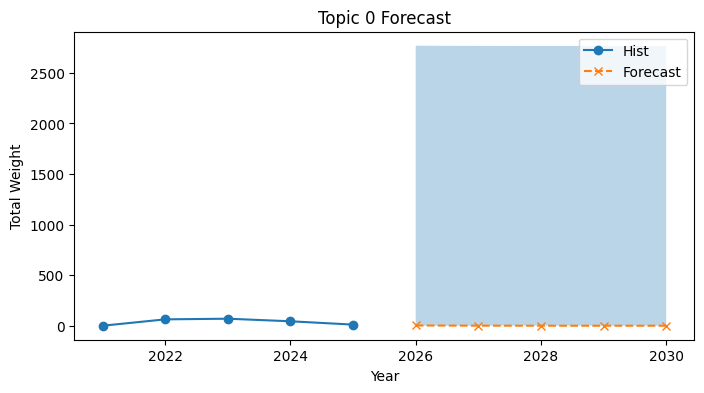

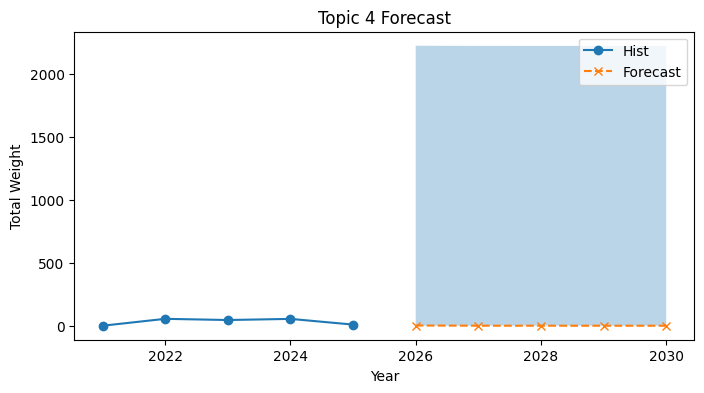

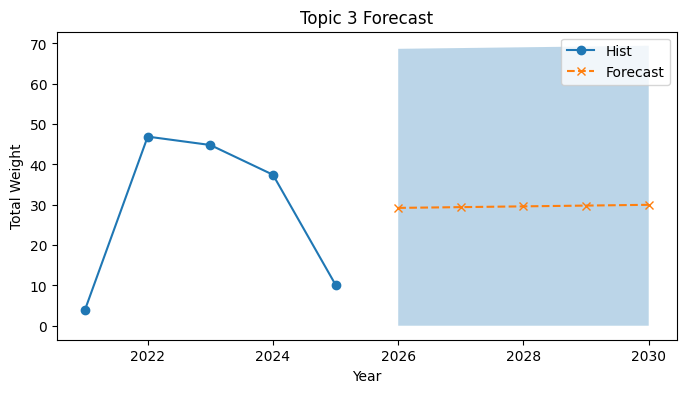

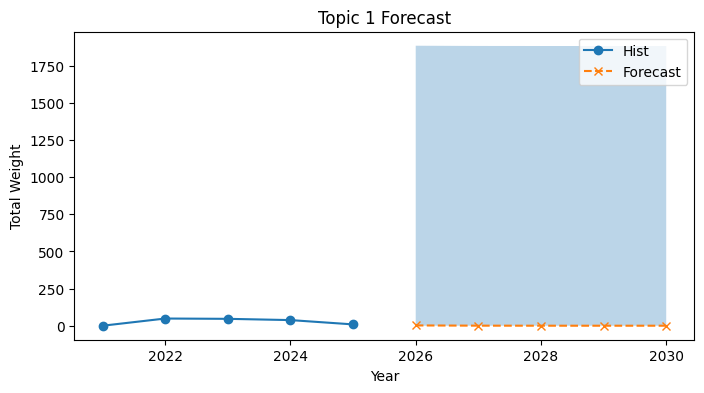

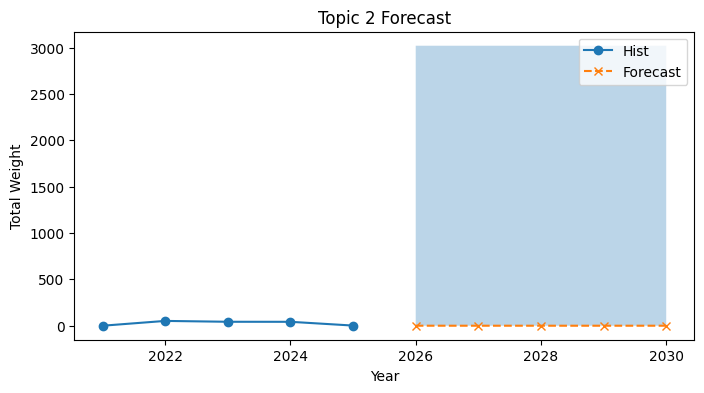

In [6]:
# %%
# 6) Plot top-5
for topic in total_weights.head(5).index:
    hist = agg[agg['topic']==topic].set_index('year')['weight']
    fdf  = forecast_results[5].query("topic == @topic")

    plt.figure()
    plt.plot(hist.index.astype(int), hist.values, 'o-', label='Hist')
    plt.plot(fdf['year'], fdf['mean'], 'x--', label='Forecast')
    plt.fill_between(fdf['year'], fdf['lower95'], fdf['upper95'], alpha=0.3)
    plt.title(f"Topic {topic} Forecast")
    plt.xlabel("Year"); plt.ylabel("Total Weight"); plt.legend(); plt.show()